In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

In [2]:
# ==========================================
# 1. Core Kalman Filter Class
# ==========================================
class KalmanFilterCV:
    """
    Implements a Constant Velocity Kalman Filter.
    State: [position, velocity]^T
    """
    def __init__(self, dt, process_noise_std, measurement_noise_std, initial_state):
        self.dt = dt
        
        # State Vector [p, v]
        self.x = np.array(initial_state).reshape(2, 1)
        
        # State Covariance Matrix P (Initial uncertainty)
        self.P = np.eye(2) * 500.0 
        
        # State Transition Matrix F
        self.F = np.array([[1, self.dt],
                           [0, 1]])
        
        # Observation Matrix H (We measure position only)
        self.H = np.array([[1, 0]])
        
        # Process Noise Covariance Q
        # We assume acceleration is the noise source driving velocity changes
        # Q structure based on discrete white noise acceleration model
        q_var = process_noise_std ** 2
        self.Q = np.array([[0.25 * dt**4, 0.5 * dt**3],
                           [0.5 * dt**3,  dt**2]]) * q_var
        
        # Measurement Noise Covariance R
        self.R = np.array([[measurement_noise_std ** 2]])

    def predict(self):
        """Prediction Step: Project state ahead."""
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x

    def update(self, z):
        """Update Step: Correction based on measurement z."""
        # Measurement Residual
        y = z - (self.H @ self.x)
        
        # Residual Covariance
        S = self.H @ self.P @ self.H.T + self.R
        
        # Optimal Kalman Gain
        K = self.P @ self.H.T @ np.linalg.inv(S)
        
        # Update State
        self.x = self.x + (K @ y)
        
        # Update Covariance
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P
        
        return self.x

In [3]:
# ==========================================
# 2. ADAS Logic & Sensor Simulation
# ==========================================
class ADASModule:
    def __init__(self):
        self.history = []
        self.alert_status = "SAFE"
        
    def calculate_ttc(self, position, velocity):
        """
        Calculates Time-To-Collision.
        Note: Velocity is negative when closing distance in this reference frame.
        """
        if velocity >= 0: 
            return float('inf') # Moving away or static
        
        ttc = abs(position / velocity)
        return ttc

    def check_safety_thresholds(self, ttc, position):
        """Multi-stage alert logic."""
        if position < 2.0: # Hard stop distance (meters)
            return "EMERGENCY_BRAKE"
        elif ttc < 1.5:
            return "EMERGENCY_BRAKE"
        elif ttc < 4.0:
            return "WARNING"
        else:
            return "SAFE"

    def log_data(self, time, raw_z, filtered_x, ttc, alert):
        entry = {
            'Time': time,
            'Raw_Position': raw_z,
            'Est_Position': filtered_x[0, 0],
            'Est_Velocity': filtered_x[1, 0],
            'TTC': ttc if ttc != float('inf') else 999,
            'Alert_State': alert
        }
        self.history.append(entry)

def simulate_ultrasonic_data(t, true_start_dist, approach_speed, noise_std):
    """Generates synthetic noisy sensor data for an approaching object."""
    true_pos = true_start_dist + (approach_speed * t) # approach_speed should be negative
    true_pos = max(0, true_pos) # Object stops at 0
    
    # Add Gaussian Noise
    measurement = true_pos + np.random.normal(0, noise_std)
    return measurement, true_pos

Starting Simulation: 10s run, Initial Dist: 40.0m, Vel: -5.0m/s
------------------------------------------------------------


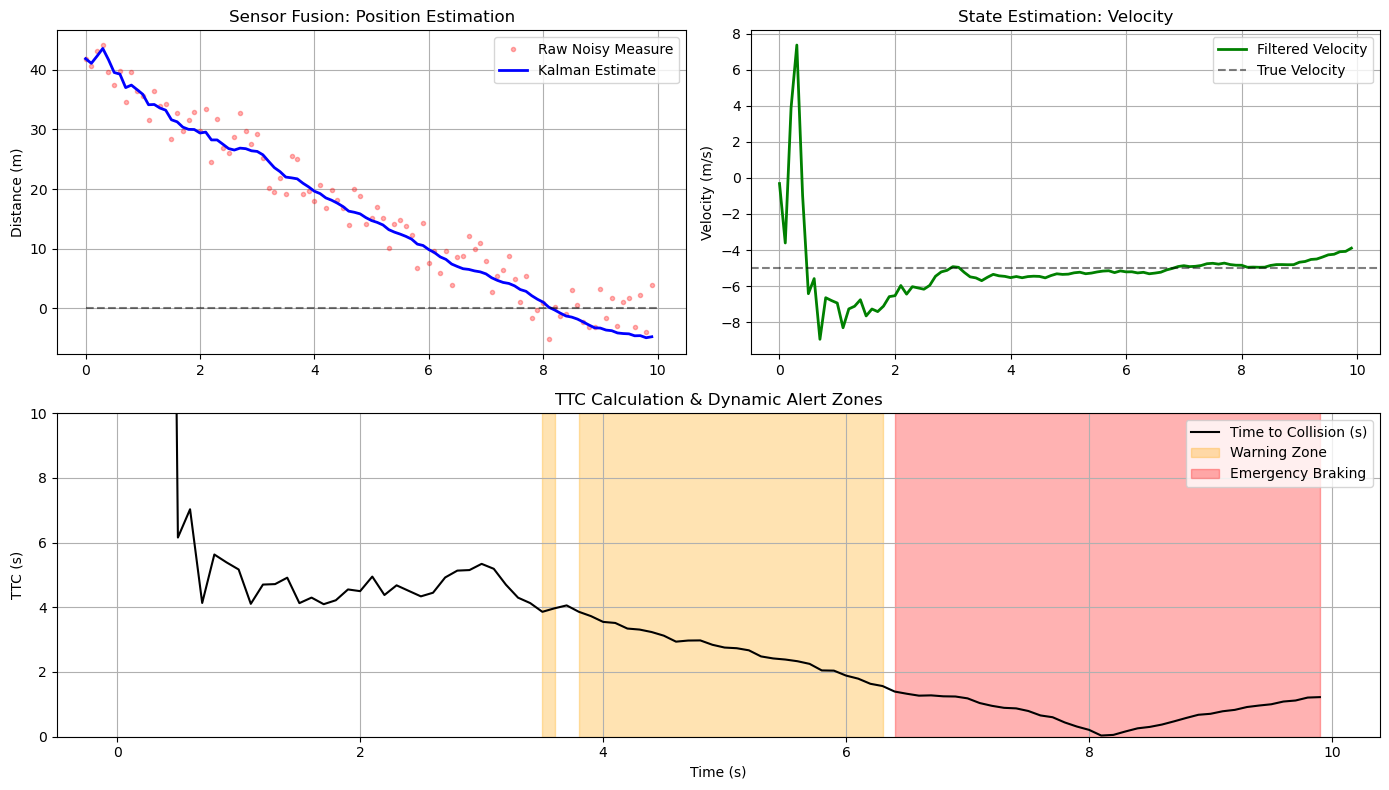


Recent Data Logs (Last 5 steps):
    Time  Raw_Position  Est_Position       TTC      Alert_State
95   9.5      1.672559     -4.279488  1.002837  EMERGENCY_BRAKE
96   9.6     -3.049801     -4.604187  1.087102  EMERGENCY_BRAKE
97   9.7      2.197166     -4.582917  1.119067  EMERGENCY_BRAKE
98   9.8     -4.013160     -4.932190  1.209960  EMERGENCY_BRAKE
99   9.9      3.972560     -4.767090  1.223618  EMERGENCY_BRAKE


In [4]:
# ==========================================
# 3. Main Simulation Pipeline
# ==========================================
def run_pipeline():
    # Simulation Parameters
    dt = 0.1  # 10Hz sampling
    total_time = 10.0
    steps = int(total_time / dt)
    
    # Initial Conditions
    start_dist = 40.0 # meters
    velocity = -5.0   # m/s (closing in)
    meas_noise_std = 2.5 # High noise to demonstrate filter capability
    
    # Initialize Objects
    kf = KalmanFilterCV(dt, process_noise_std=0.5, measurement_noise_std=meas_noise_std, initial_state=[start_dist+5, 0])
    adas = ADASModule()
    
    print(f"Starting Simulation: 10s run, Initial Dist: {start_dist}m, Vel: {velocity}m/s")
    print("-" * 60)
    
    # Real-time Loop Simulation
    for k in range(steps):
        t = k * dt
        
        # 1. Simulate Sensor Reading (Get Raw Data)
        z_meas, true_pos = simulate_ultrasonic_data(t, start_dist, velocity, meas_noise_std)
        
        # 2. Kalman Prediction
        kf.predict()
        
        # 3. Kalman Update (Fusion)
        est_state = kf.update(z_meas)
        est_pos = est_state[0, 0]
        est_vel = est_state[1, 0]
        
        # 4. ADAS Logic (TTC)
        ttc = adas.calculate_ttc(est_pos, est_vel)
        alert = adas.check_safety_thresholds(ttc, est_pos)
        
        # 5. Logging
        adas.log_data(t, z_meas, est_state, ttc, alert)
    # ==========================================
    # 4. Visualization & Analysis
    # ==========================================
    df = pd.DataFrame(adas.history)
    
    plt.figure(figsize=(14, 8))
    
    # Subplot 1: Position Tracking
    plt.subplot(2, 2, 1)
    plt.plot(df['Time'], df['Raw_Position'], 'r.', alpha=0.3, label='Raw Noisy Measure')
    plt.plot(df['Time'], df['Est_Position'], 'b-', linewidth=2, label='Kalman Estimate')
    plt.plot([0, total_time], [0, 0], 'k--', alpha=0.5) # Impact line
    plt.title("Sensor Fusion: Position Estimation")
    plt.ylabel("Distance (m)")
    plt.grid(True)
    plt.legend()

    # Subplot 2: Velocity Estimation
    plt.subplot(2, 2, 2)
    plt.plot(df['Time'], df['Est_Velocity'], 'g-', linewidth=2, label='Filtered Velocity')
    plt.axhline(y=velocity, color='k', linestyle='--', alpha=0.5, label='True Velocity')
    plt.title("State Estimation: Velocity")
    plt.ylabel("Velocity (m/s)")
    plt.grid(True)
    plt.legend()
    
    # Subplot 3: TTC & Alerts
    plt.subplot(2, 1, 2)
    # Map alerts to numeric levels for plotting
    alert_map = {'SAFE': 0, 'WARNING': 1, 'EMERGENCY_BRAKE': 2}
    alert_numeric = df['Alert_State'].map(alert_map)
    
    plt.plot(df['Time'], df['TTC'], 'k-', label='Time to Collision (s)')
    plt.fill_between(df['Time'], 0, 10, where=(alert_numeric==1), color='orange', alpha=0.3, label='Warning Zone')
    plt.fill_between(df['Time'], 0, 10, where=(alert_numeric==2), color='red', alpha=0.3, label='Emergency Braking')
    
    plt.ylim(0, 10)
    plt.title("TTC Calculation & Dynamic Alert Zones")
    plt.xlabel("Time (s)")
    plt.ylabel("TTC (s)")
    plt.legend(loc='upper right')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Display Data Sample
    print("\nRecent Data Logs (Last 5 steps):")
    print(df[['Time', 'Raw_Position', 'Est_Position', 'TTC', 'Alert_State']].tail())

if __name__ == "__main__":
    run_pipeline()
    